<font size="6">Tutorial — Fitting and stacking galaxy-cluster weak-lensing profiles</font>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
plt.rcParams.update({"font.size": 12, "figure.figsize": (6, 4)})
np.random.seed(2807)
print("pymc", pm.__version__, "| numpy", np.__version__)

/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


pymc 5.28.5 | numpy 2.4.6


<font size='5'>1. A cluster profile is a (declining) line in log–log space</font>

For a galaxy cluster, we know the weak-lensing profile is high at small radius and falls off at larger radii. In log-log space this is a straight line with:

$log_{10}$&Sigma;(r) = a - b$log_{10}(r/r_{piv})

<ul>
    <li>a = an amplitude which scales with the cluster mass. </li>
    <li>b = the slope, which is steeper for more concentrated clusters.</li>
</ul>

Fitting a log profile, or fitting a line with parameters &Theta; = (a,b) set of data points as a model of the log-log relationship of radius and the surface mass density


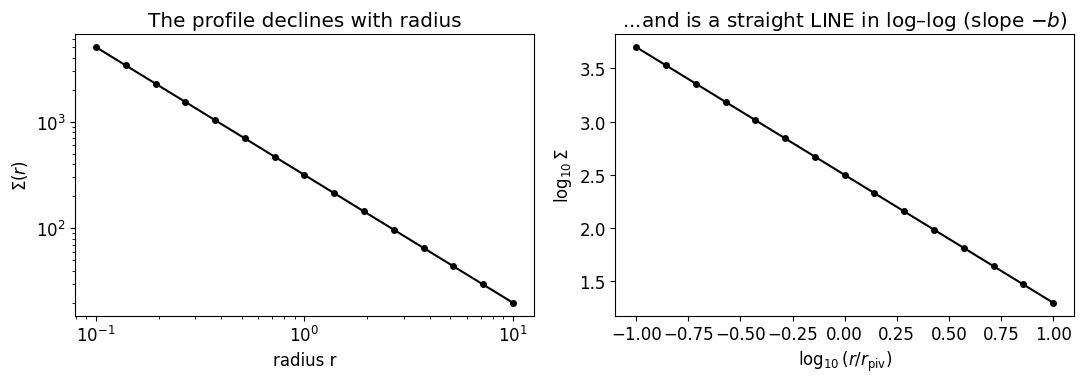

In [2]:
radii = np.logspace(-1, 1, 15)            # 15 radial bins, r = 0.1 .. 10 (e.g. arcmin or Mpc)
r_pivot = 1.0
log_r = np.log10(radii / r_pivot)         # the line's x-axis

def profile_model(theta):
    # log10 Sigma(r) = a - b log10(r/r_piv).  theta = (amplitude a, slope b).
    a, b = theta
    return a - b * log_r

a_true, b_true = 2.5, 1.2                  # one example cluster
log_sigma_true = profile_model((a_true, b_true))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(radii, 10**log_sigma_true, "k-o", ms=4)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("radius r"); ax[0].set_ylabel(r"$\Sigma(r)$")
ax[0].set_title("The profile declines with radius")
ax[1].plot(log_r, log_sigma_true, "k-o", ms=4)
ax[1].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$"); ax[1].set_ylabel(r"$\log_{10}\Sigma$")
ax[1].set_title("...and is a straight LINE in log–log (slope $-b$)")
plt.tight_layout(); plt.show()

Again, modelling the log-normal prediction plot but now with slight noise at each radius value. We model this a Gaussian in log

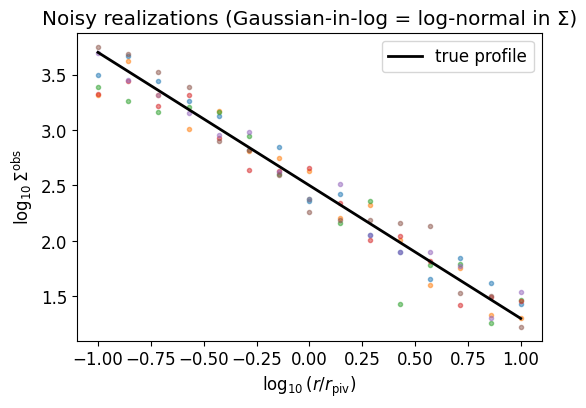

In [3]:
noise_dex = 0.15                                   # per-bin 1-sigma noise in log10 Sigma ("dex")
def observe(theta, sigma=noise_dex):
    # one noisy profile (a data VECTOR of length N_r)
    return profile_model(theta) + sigma * np.random.randn(len(radii))

plt.figure()
for _ in range(6):                                # several noisy realizations of the SAME cluster
    plt.plot(log_r, observe((a_true, b_true)), ".", alpha=0.5)
plt.plot(log_r, log_sigma_true, "k-", lw=2, label="true profile")
plt.xlabel(r"$\log_{10}(r/r_{\rm piv})$"); plt.ylabel(r"$\log_{10}\Sigma^{\rm obs}$")
plt.title("Noisy realizations (Gaussian-in-log = log-normal in Σ)"); plt.legend(); plt.show()

data_one = observe((a_true, b_true))               # the ONE cluster we will fit next

<font size='5'>2. Inferring one cluster — and seeing the prior, likelihood, and posterior</font>

<strong>Prior</strong>: flat (uniform) on a sensible box for (a,b), <strong>Posterior</strong>: Proportional to likelihood x prior

The model is linear and the noise is Gaussian, as previously shown, thus we can draw the prior, likelihood, and posterior as maps over the parameter plan (a,b).

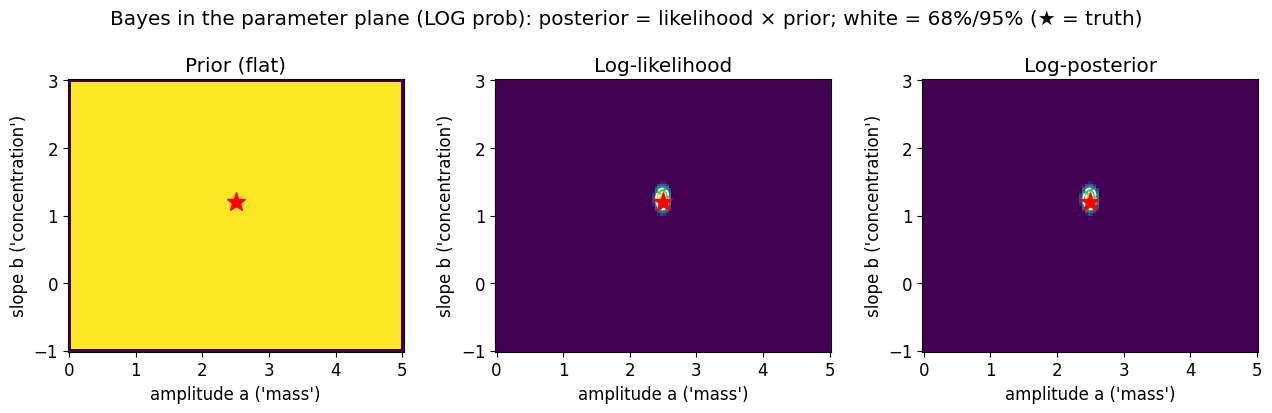

In [4]:
def log_likelihood(theta, d, sigma=noise_dex):
    resid = d - profile_model(theta)
    return -0.5 * np.sum(resid**2 / sigma**2)

A_LO, A_HI, B_LO, B_HI = 0.0, 5.0, -1.0, 3.0       # the flat-prior box for (a, b)
def log_prior(theta):
    a, b = theta
    return 0.0 if (A_LO < a < A_HI and B_LO < b < B_HI) else -np.inf

def log_posterior(theta, d, sigma=noise_dex):
    lp = log_prior(theta)
    return -np.inf if not np.isfinite(lp) else lp + log_likelihood(theta, d, sigma)

# Evaluate prior / likelihood / posterior on a grid over the (a,b) plane.
agrid = np.linspace(A_LO, A_HI, 120); bgrid = np.linspace(B_LO, B_HI, 120)
AA, BB = np.meshgrid(agrid, bgrid, indexing="ij")
model_cube = AA[..., None] - BB[..., None] * log_r          # predicted profile at every (a,b)
chi2 = np.sum((data_one - model_cube)**2 / noise_dex**2, axis=-1)
# Work in LOG probability -- the linear likelihood is far too sharply peaked to see as a color map.
loglike  = -0.5 * (chi2 - chi2.min())                       # log-likelihood (relative to its peak)
logprior = np.where((AA > A_LO) & (AA < A_HI) & (BB > B_LO) & (BB < B_HI), 0.0, -50.0)  # flat prior (log)
logpost  = loglike + logprior; logpost -= logpost.max()     # log posterior = log likelihood + log prior
levels = [-3.09, -1.15]                                     # 95% / 68% credible (Delta 2 lnL = 6.18, 2.30)

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
panels = [("Prior (flat)",   np.clip(logprior, -8, 0),               None),
          ("Log-likelihood", np.clip(loglike - loglike.max(), -8, 0), loglike - loglike.max()),
          ("Log-posterior",  np.clip(logpost, -8, 0),                 logpost)]
for axi, (title, shade, cont) in zip(ax, panels):
    axi.pcolormesh(AA, BB, shade, shading="auto", cmap="viridis")
    if cont is not None: axi.contour(AA, BB, cont, levels=levels, colors="white", linewidths=1.2)
    axi.plot(a_true, b_true, "r*", ms=14)
    axi.set_xlabel("amplitude a ('mass')"); axi.set_ylabel("slope b ('concentration')"); axi.set_title(title)
fig.suptitle("Bayes in the parameter plane (LOG prob): posterior = likelihood × prior; white = 68%/95% (★ = truth)")
plt.tight_layout(); plt.show()

With a flat prior the posterior is just the likelihood (an informative prior would multiply in and reshape it)

In [5]:

with pm.Model() as model:

    # priors
    a = pm.Uniform("a", lower=A_LO, upper=A_HI)
    b = pm.Uniform("b", lower=B_LO, upper=B_HI)

    # deterministic profile
    mu = a - b * log_r

    # likelihood
    pm.Normal(
        "obs",
        mu=mu,
        sigma=noise_dex,
        observed=data_one,
    )

    trace = pm.sample(
        draws=2000,
        tune=500,
        chains=4,
        target_accept=0.9,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 1 seconds.


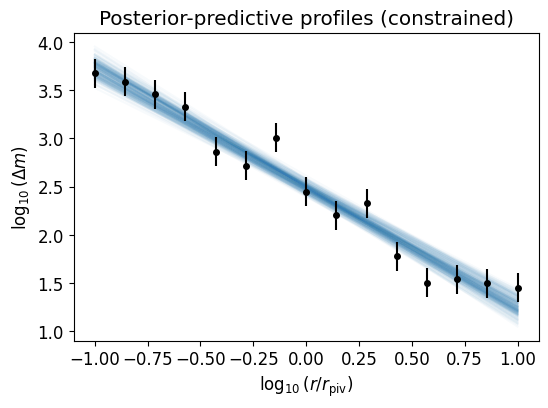

a = 2.4920643527890647 +/- 0.03882429651765602
b = 1.2464276959638496 +/- 0.0636697436953224


In [6]:
posterior = trace.posterior

a_samples = posterior["a"].values.flatten()
b_samples = posterior["b"].values.flatten()

fig, ax = plt.subplots(figsize=(6,4))

for i in np.random.choice(len(a_samples), 200, replace=False):
    mu_i = a_samples[i] - b_samples[i] * log_r

    ax.plot(
        log_r,
        mu_i,
        color="tab:blue",
        alpha=0.03
    )

ax.errorbar(
    log_r,
    data_one,
    yerr=noise_dex,
    fmt="ko",
    ms=4
)
plt.title("Posterior-predictive profiles (constrained)"); plt.xlabel(r"$\log_{10}(r/r_{\rm piv})$"); plt.ylabel(r"$\log_{10}(\Delta m)$")
plt.show()
print("a =", a_samples.mean(), "+/-", a_samples.std())
print("b =", b_samples.mean(), "+/-", b_samples.std())


<font size='5'>3. A population of clusters (the generative model)</font>

As real clusters are not actually identical, we model that now by modeling the population as a Gaussian with <strong>hyper-parameters = </strong> the population mean <strong>&mu;</strong> amd the <strong>intrinsic scatter s</strong>.

We fix the true values for these for now; later on we will show how to recover this.

Initializing NUTS using jitter+adapt_diag...


TRUE hyper-parameters:  population mean = [2.5 1.2]   intrinsic scatter = [0.25 0.3 ]


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_a, mu_b, sigma_a, sigma_b, a, b]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


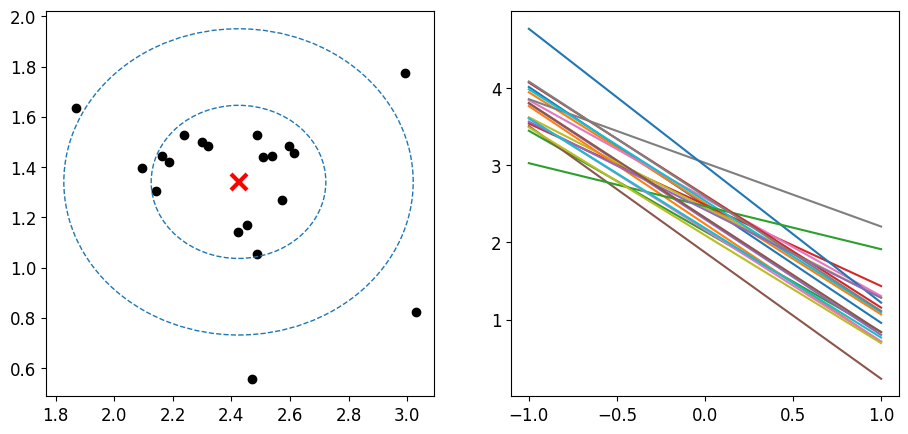

In [7]:
n_clusters = 20
mu_pop = np.array([2.50, 1.20])      # TRUE population mean of (amplitude, slope)
s_pop  = np.array([0.25, 0.30])      # TRUE intrinsic scatter (cluster-to-cluster)
print("TRUE hyper-parameters:  population mean =", mu_pop, "  intrinsic scatter =", s_pop)

theta_true = mu_pop + s_pop * np.random.randn(n_clusters, 2)         # each cluster's true (a,b)
profiles   = np.array([profile_model(theta_true[j]) + noise_dex*np.random.randn(len(radii))
                       for j in range(n_clusters)])                  # their noisy profiles

with pm.Model() as hierarchical_model:

    # population mean
    mu_a = pm.Normal("mu_a", mu=2.5, sigma=1)
    mu_b = pm.Normal("mu_b", mu=1.2, sigma=1)

    # population scatter
    sigma_a = pm.HalfNormal("sigma_a", sigma=0.5)
    sigma_b = pm.HalfNormal("sigma_b", sigma=0.5)

    # cluster-level parameters
    a = pm.Normal(
        "a",
        mu=mu_a,
        sigma=sigma_a,
        shape=n_clusters
    )

    b = pm.Normal(
        "b",
        mu=mu_b,
        sigma=sigma_b,
        shape=n_clusters
    )

    # expected profiles
    mu_profile = (
        a[:, None]
        - b[:, None] * log_r[None, :]
    )

    # likelihood
    pm.Normal(
        "obs",
        mu=mu_profile,
        sigma=noise_dex,
        observed=profiles
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9
    )
    import arviz as az
mu_a_post = trace.posterior["mu_a"].values.mean()
mu_b_post = trace.posterior["mu_b"].values.mean()

sig_a_post = trace.posterior["sigma_a"].values.mean()
sig_b_post = trace.posterior["sigma_b"].values.mean()

a_post = trace.posterior["a"].values.mean(axis=(0,1))
b_post = trace.posterior["b"].values.mean(axis=(0,1))

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(1,2,figsize=(11,5))

ax[0].scatter(a_post, b_post, c="k")

for nsig in [1,2]:
    ax[0].add_patch(
        Ellipse(
            (mu_a_post, mu_b_post),
            2*nsig*sig_a_post,
            2*nsig*sig_b_post,
            fill=False,
            ls="--",
            color="tab:blue"
        )
    )

ax[0].plot(
    mu_a_post,
    mu_b_post,
    "rx",
    ms=12,
    mew=3
)


for i in range(n_clusters):

    profile_i = (
        a_post[i]
        - b_post[i]*log_r
    )

    ax[1].plot(log_r, profile_i)

plt.show()

<font size='5'>4. Stacking: two strategies (and the bug)</font>

To help tamp down the noise we show three methods for combining $N_c$ clusters:

<strong>Join-then-fit (JtF)</strong> — average the data first, then fit once.

<strong>Fit-then-join (FtJ), as printed in the paper</strong> — compares the model to every cluster but divides by $N_c$

<strong>Correct joint</strong> — independent clusters multiply their likelihoods, so the logs add (no $1/N_c$)

In [8]:
def fits(nc):
    n_clusters=nc
    theta_true = mu_pop + s_pop * np.random.randn(n_clusters, 2)   
    profiles   = np.array([profile_model(theta_true[j]) + noise_dex*np.random.randn(len(radii))
                       for j in range(n_clusters)])
    median_profile = np.median(profiles, axis=0)
    sigma_tilde_sq = (np.pi/2) * noise_dex**2 / n_clusters
    def with_prior(loglike):
        return lambda th: loglike(th) if np.isfinite(log_prior(th)) else -np.inf

    ll_JtF   = lambda th: -0.5 * np.sum((median_profile - profile_model(th))**2 / sigma_tilde_sq)
    ll_FtJ   = lambda th: -(1/(2*n_clusters)) * np.sum((profiles - profile_model(th))**2 / noise_dex**2)
    ll_joint = lambda th: -0.5 * np.sum((profiles - profile_model(th))**2 / noise_dex**2)
    with pm.Model() as jtf_model:

        a = pm.Uniform("a", lower=A_LO, upper=A_HI)
        b = pm.Uniform("b", lower=B_LO, upper=B_HI)

        mu = a - b*log_r

        pm.Normal(
            "obs",
            mu=mu,
            sigma=np.sqrt(sigma_tilde_sq),
            observed=median_profile,
        )

        trace_jtf = pm.sample()
    with pm.Model() as joint_model:

        a = pm.Uniform("a", lower=A_LO, upper=A_HI)
        b = pm.Uniform("b", lower=B_LO, upper=B_HI)

        mu = a - b*log_r

        pm.Normal(
            "obs",
            mu=mu,
            sigma=noise_dex,
            observed=profiles,
        )

        trace_joint = pm.sample()
    with pm.Model() as ftj_model:

        a = pm.Uniform("a", lower=A_LO, upper=A_HI)
        b = pm.Uniform("b", lower=B_LO, upper=B_HI)

        mu = a - b*log_r

        pm.Normal(
            "obs",
            mu=mu,
            sigma=np.sqrt(n_clusters)*noise_dex,
            observed=profiles,
        )

        trace_ftj = pm.sample()

    a_jtf = trace_jtf.posterior["a"].values.flatten()
    a_ftj = trace_ftj.posterior["a"].values.flatten()
    a_joint = trace_joint.posterior["a"].values.flatten()

    print("JtF =", a_jtf.std())
    print("FtJ =", a_ftj.std())
    print("joint =", a_joint.std())
    print("FtJ/JtF = ", a_ftj.std()/a_jtf.std())
    print("FtJ/joint = ", a_ftj.std()/a_joint.std())
    return trace_jtf, trace_ftj, trace_joint
fits(5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


JtF = 0.02232263059235436
FtJ = 0.039188049552080946
joint = 0.017503747470645325
FtJ/JtF =  1.7555300836946655
FtJ/joint =  2.2388376899176192


(Inference data with groups:
 	> posterior
 	> sample_stats
 	> observed_data,
 Inference data with groups:
 	> posterior
 	> sample_stats
 	> observed_data,
 Inference data with groups:
 	> posterior
 	> sample_stats
 	> observed_data)

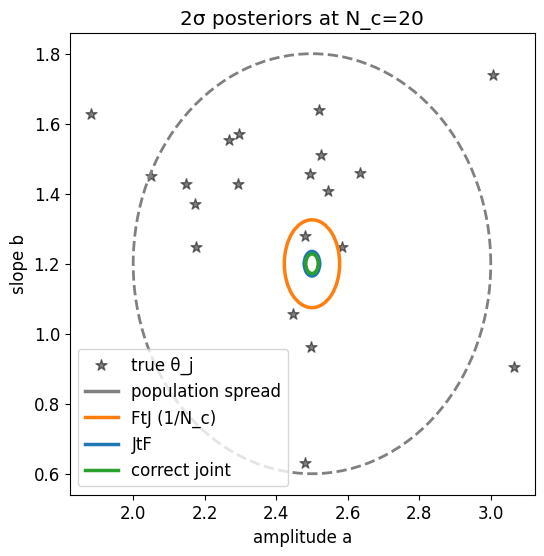

In [10]:
sigma_tilde_sq = (np.pi/2) * noise_dex**2 / n_clusters
from matplotlib.patches import Ellipse
def cov_ellipse(ax, c, cov, n=2, **kw):
    v, V = np.linalg.eigh(cov); o = v.argsort()[::-1]; v, V = v[o], V[:, o]
    ang = np.degrees(np.arctan2(V[1, 0], V[0, 0])); ax.add_patch(Ellipse(c, *(2*n*np.sqrt(v)), angle=ang, fill=False, **kw))
XtX_inv = np.linalg.inv((np.column_stack([np.ones_like(log_r), -log_r])).T @ np.column_stack([np.ones_like(log_r), -log_r]))
fig, ax = plt.subplots(figsize=(6, 6)); c = mu_pop
ax.scatter(theta_true[:, 0], theta_true[:, 1], marker="*", s=70, color="k", alpha=0.5, label="true θ_j")
cov_ellipse(ax, c, np.diag(s_pop**2), color="gray", lw=2, ls="--"); cov_ellipse(ax, c, noise_dex**2*XtX_inv, color="tab:orange", lw=2.5)
cov_ellipse(ax, c, sigma_tilde_sq*XtX_inv, color="tab:blue", lw=2.5); cov_ellipse(ax, c, noise_dex**2/n_clusters*XtX_inv, color="tab:green", lw=2.5)
for lab, col in [("population spread", "gray"), ("FtJ (1/N_c)", "tab:orange"), ("JtF", "tab:blue"), ("correct joint", "tab:green")]:
    ax.plot([], [], color=col, lw=2.5, label=lab)
ax.set_xlabel("amplitude a"); ax.set_ylabel("slope b"); ax.set_title("2σ posteriors at N_c=20"); ax.legend(); plt.show()

<em>Reading the ellipse:</em> its size is the uncertainty, its tilt is the correlation between the two parameters, and its principal axes are the eigenvectors of the covariance matrix. Notice the orange FtJ ellipse is nearly as large as the gray population spread — that is the bug, not a feature

<font size='5'>5. The diagnostic: does adding clusters help?</font>

We work through showing that stacking should converge the answer as $1/$&radic;$N_c$

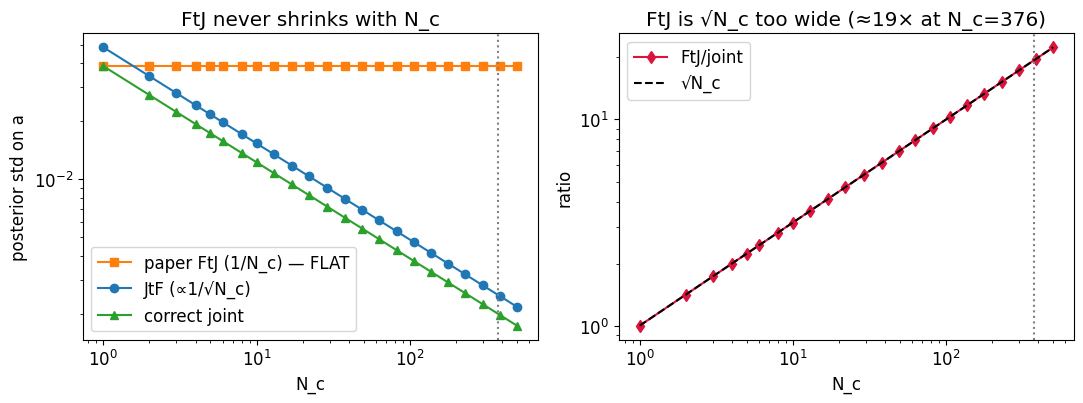

In [11]:
w0 = np.sqrt(XtX_inv[0, 0]); Nc = np.unique(np.round(np.logspace(0, 2.7, 25)).astype(int))
W_JtF = np.sqrt(np.pi/2)*noise_dex*w0/np.sqrt(Nc); W_jnt = noise_dex*w0/np.sqrt(Nc); W_FtJ = noise_dex*w0*np.ones_like(Nc, float)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].loglog(Nc, W_FtJ, "s-", color="tab:orange", label="paper FtJ (1/N_c) — FLAT"); ax[0].loglog(Nc, W_JtF, "o-", color="tab:blue", label="JtF (∝1/√N_c)")
ax[0].loglog(Nc, W_jnt, "^-", color="tab:green", label="correct joint"); ax[0].axvline(376, color="gray", ls=":")
ax[0].set_xlabel("N_c"); ax[0].set_ylabel("posterior std on a"); ax[0].set_title("FtJ never shrinks with N_c"); ax[0].legend()
ax[1].loglog(Nc, W_FtJ/W_jnt, "d-", color="crimson", label="FtJ/joint"); ax[1].loglog(Nc, np.sqrt(Nc), "k--", label="√N_c"); ax[1].axvline(376, color="gray", ls=":")
ax[1].set_xlabel("N_c"); ax[1].set_ylabel("ratio"); ax[1].set_title("FtJ is √N_c too wide (≈19× at N_c=376)"); ax[1].legend(); plt.tight_layout(); plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


...

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


JtF = 0.005382050690538882
FtJ = 0.03888316510027685
joint = 0.0042257714058389064
FtJ/JtF =  7.224600312410591
FtJ/joint =  9.201435990255062


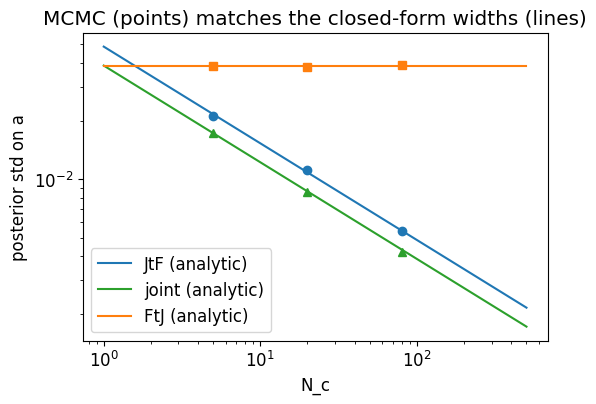

In [12]:
meas = {"JtF": [], "joint": [], "FtJ": []}
Nc_test=[5,20,80]
for nc in Nc_test:
    trace_jtf, trace_ftj, trace_joint = fits(nc)
    w_jtf = trace_jtf.posterior["a"].values.flatten().std()
    w_joint = trace_joint.posterior["a"].values.flatten().std()
    w_ftj = trace_ftj.posterior["a"].values.flatten().std()
    meas["JtF"].append(w_jtf)
    meas["joint"].append(w_joint)
    meas["FtJ"].append(w_ftj)
plt.figure()
plt.loglog(Nc, W_JtF, "-", color="tab:blue", label="JtF (analytic)"); plt.loglog(Nc_test, meas["JtF"], "o", color="tab:blue")
plt.loglog(Nc, W_jnt, "-", color="tab:green", label="joint (analytic)"); plt.loglog(Nc_test, meas["joint"], "^", color="tab:green")
plt.loglog(Nc, W_FtJ, "-", color="tab:orange", label="FtJ (analytic)"); plt.loglog(Nc_test, meas["FtJ"], "s", color="tab:orange")
plt.xlabel("N_c"); plt.ylabel("posterior std on a"); plt.title("MCMC (points) matches the closed-form widths (lines)"); plt.legend(); plt.show()

<strong>The Bug.</strong> The per-cluster information is a sum that turns into an average as a result of the $1/N_c$. This would be the precision of a single cluster and thus independent of $N_c$. JtF and the correct joint do not tighten as this, but rather as $1/N_c$ so our fix is to use a sum (drop the $1/N_c$).

<font size="5">6. The real NFW profile</font>

All of the above has been a toy to model the power law; a real cluster is an NFW not necessarily an exact power law. Now we plot a real NFW surface-density profile and fit a stacked sample in two correct ways - join-then-fit (median) and the correct joint (sum likelihood) - and show their posterior contours.

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [log10M]
>Metropolis: [c]


Output()

Sampling 4 chains for 2_000 tune and 5_000 draw iterations (8_000 + 20_000 draws total) took 2 seconds.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [log10M]
>Metropolis: [c]


Output()

Sampling 4 chains for 2_000 tune and 5_000 draw iterations (8_000 + 20_000 draws total) took 2 seconds.


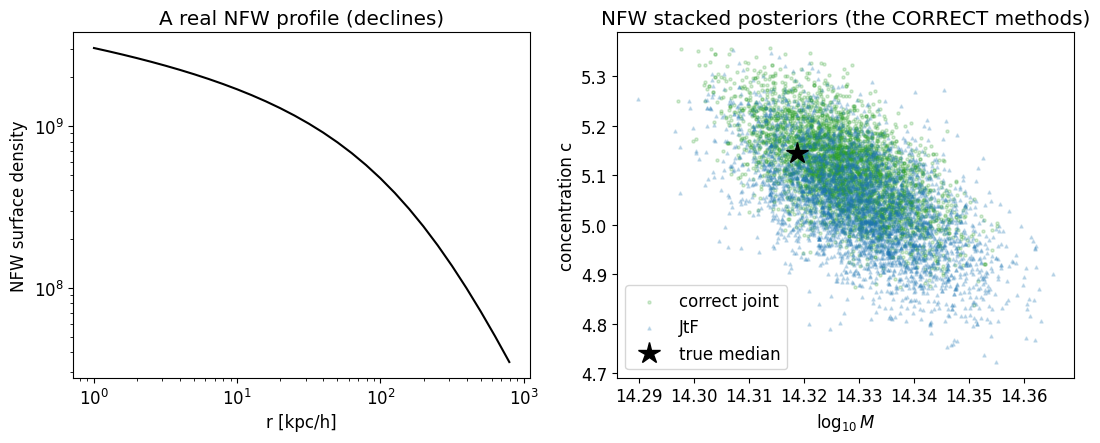

NFW stacked widths log10M:  JtF=0.011  correct-joint=0.009  (the buggy 1/N_c FtJ would be ~sqrt(N_c) wider)


In [13]:
import pytensor.tensor as pt
from colossus.cosmology import cosmology 
from colossus.halo import profile_nfw
cosmology.setCosmology("planck18") 
#this is the specific R array that we are going to use in log_surfaceDensity
#We could hardcode this, but this is more flexible if we want to change the range of R 
# and it lines up better with original code
nfw_r = 10**np.arange(0, 3, 0.1)
#this replaces the nfw_logSigma function as it is now a method of the NFWProfile class
def nfw_logSigma(theta):                         # theta = (log10 mass, concentration)
        h = profile_nfw.NFWProfile(M=10**theta[0], c=theta[1], z=0.0, mdef="vir")
        return np.log10(h.surfaceDensity(nfw_r))
class NFWProfile:
    def __init__(self, M, c, z=0.0, mdef="vir"):
        self.M = M
        self.c = c
        self.z = z
        self.mdef = mdef
        self.rhos,self.rs = profile_nfw.NFWProfile.nativeParameters(M=self.M, c=self.c, z=self.z, mdef=self.mdef)
    
    def print_type(self):
        print(type(self.rhos), type(self.rs))

    
    def density(self, R):
        # Placeholder for actual NFW density calculation
        return self.rhos / ((R / self.rs) * (1 + R / self.rs)**2)
    
    #for P:
    def f_function_np(self, x):
        if x<1:
            return (1/(x**2-1))*(1-(2/np.sqrt(1-x**2))*np.arctanh(np.sqrt((1-x)/(1+x))))
        elif x==1:
            return 1/3
        else:
            return (1/(x**2-1))*(1-(2/np.sqrt(x**2-1))*np.arctan(np.sqrt((x-1)/(1+x))))
    def log_surfaceDensity_np(self, R):
        # Placeholder for actual surface density calculation
        integrand = np.zeros((len(R)), dtype=float)
        for j in range(len(R)):
            if R[j] <= 0:
                raise ValueError("R must be positive")
            integrand[j] = 2*self.rhos*self.rs*self.f_function_np(R[j]/self.rs)
        return np.log10(integrand)  # Return log10 of the integral values
    
    
    #with the tensor
    def f_function(self, x):
        f_lt = (1/(x**2-1))*(1-(2/pt.sqrt(1-x**2))*pt.arctanh(pt.sqrt((1-x)/(1+x))))
        f_eq = 1.0/3.0
        f_gt = (1/(x**2-1))*(1-(2/pt.sqrt(x**2-1))*pt.arctan(pt.sqrt((x-1)/(1+x))))

        f = pt.switch(
            pt.lt(x, 1),
            f_lt,
            pt.switch(
                pt.gt(x, 1),
                f_gt,
                f_eq
            )
        )
        return f

        return np.log10(integrand)  # Return log10 of the integral values
    def log_surfaceDensity(self, R):
        # Placeholder for actual surface density calculation
        integrand = []
        for j in range(len(R)):
            if R[j] <= 0:
                raise ValueError("R must be positive")
            integrand.append(2*self.rhos*self.rs*self.f_function(R[j]/self.rs))
        answer=pt.stack(integrand)
        return np.log10(answer)  # Return log10 of the integral values

th0 = np.array([14.3, 5.0]); dex = 0.10
# population of NFW clusters + noisy profiles
Nc2 = 20
m = 14.3 + 0.10*np.random.randn(Nc2)
cc = 5.0 + 0.7*np.random.randn(Nc2)
###NFWProfile(M=10**m[0], c=cc[0]).print_type()  # Print the native parameters for the first cluster
P = np.array([
    NFWProfile(M=10**m[j], c=cc[j]).log_surfaceDensity_np(nfw_r)
    + dex*np.random.randn(len(nfw_r))
    for j in range(Nc2)
])
med = np.median(P, axis=0); st2 = (np.pi/2)*dex**2/Nc2
inb = lambda t: 13.5 < t[0] < 15 and 1 < t[1] < 12

with pm.Model() as jtf_model:
    log10M = pm.Uniform("log10M", 13.5, 15)
    c = pm.Uniform("c", 1, 12)
    prediction = NFWProfile(M=10**log10M, c=c).log_surfaceDensity(nfw_r)
    pm.Normal(
        "obs",
        mu=prediction,
        sigma=np.sqrt(st2),
        observed=med
    )
    jtf_trace = pm.sample(
        step=pm.Metropolis(),
        draws=5000,
        tune=2000
    )

with pm.Model() as joint_model:
    log10M = pm.Uniform("log10M", 13.5, 15)
    c = pm.Uniform("c", 1, 12)
    prediction = NFWProfile(M=10**log10M, c=c).log_surfaceDensity(nfw_r)
    pm.Normal(
        "profiles",
        mu=prediction,
        sigma=dex,
        observed=P
    )
    joint_trace = pm.sample(
        step=pm.Metropolis(),
        draws=5000,
        tune=2000
    )
    
s_j = np.column_stack([
    jtf_trace.posterior["log10M"].values.flatten(),
    jtf_trace.posterior["c"].values.flatten()
])

s_c = np.column_stack([
    joint_trace.posterior["log10M"].values.flatten(),
    joint_trace.posterior["c"].values.flatten()
    ])
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
ax[0].plot(nfw_r, 10**nfw_logSigma(th0), "k-"); ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("r [kpc/h]"); ax[0].set_ylabel("NFW surface density"); ax[0].set_title("A real NFW profile (declines)")
ax[1].scatter(s_c[::5, 0], s_c[::5, 1], s=5, alpha=0.2, marker="o", color="tab:green", label="correct joint")
ax[1].scatter(s_j[::5, 0], s_j[::5, 1], s=5, alpha=0.2, marker="^", color="tab:blue", label="JtF")
ax[1].plot(np.median(m), np.median(cc), "k*", ms=16, label="true median")
ax[1].set_xlabel(r"$\log_{10} M$"); ax[1].set_ylabel("concentration c"); ax[1].set_title("NFW stacked posteriors (the CORRECT methods)"); ax[1].legend()
plt.tight_layout(); plt.show()
print("NFW stacked widths log10M:  JtF=%.3f  correct-joint=%.3f  (the buggy 1/N_c FtJ would be ~sqrt(N_c) wider)"
        % (s_j[:, 0].std(), s_c[:, 0].std()))

<font size='5'>7. Hierarchical Bayesian Inference: the hyper-posterior</font>

JtF and FtJ all estimate one shared &Theta; - the population mean. To get the intrinsic scatter in addition to the population mean we use a hierarchical model: each cluster j has its own &Theta;<sub>j</sub> = ($a_j$,$b_j$), drawn from a population with hyper-parameters &Alpha;

In a real survey, the "stored per-cluster posterior" for cluster is the chain a WL pipeline outputs after fitting that cluster's shear profile. The hierarchical machinery below does not know or care that we generated those posteriors here — it only needs samples.

<font size='4'>7.0 Warm-up - Same Identity in 1-D</font>

Before fitting the 2-parameter line, let's see the three estimators on the cleanest possible hierarchical-normal toy so the bias is unambiguous and the math fits on one screen:

<ul>
    <li>truth: a_j ~ &Nscr;(&mu;,&tau;<sup>2</sup>)&mu; = 2.50, &tau; = 0.25</li>
    <li>observation: one scalar per cluster, d_j = a_j + &Nscr;(0,&sigma;<sup>2</sup><sub>obs</sub>)</li>
    <li>per-cluster posterior (flat prior &pi;<sub>0</sub>):p($a_j$ | $d_j$) = &Nscr;($d_j$, &sigma;<sup>2</sup><sub>obs</sub>) - analytic, no MCMC
</ul>

We pick &sigma;<sub>obs</sub> = 0.40 so &sigma;<sub>obs</sub> > &tau; (per-cluster posteriors are broader than the true population - the regime where the bias is dramatic) and $N_c$ = 200

In [14]:
# ---------- 1-D warm-up ----------
mu_w, tau_w, sig_w = 2.50, 0.25, 0.40                    # truth + measurement noise
N_w = 200                                                 # 200 clusters
a_true_w = mu_w + tau_w * np.random.randn(N_w)            # latent
d_w      = a_true_w + sig_w * np.random.randn(N_w)        # one observation per cluster

# per-cluster posterior is exactly N(d_j, sig_w^2)  ->  S=4000 samples each
S_w = 4000
post_w = d_w[:, None] + sig_w * np.random.randn(N_w, S_w)   # shape (N_c, S)

# Attempt 1: naive pool of ALL samples
tau_pool_w = post_w.ravel().std()
# Attempt 2: OLS on per-cluster posterior means (= d_j here)
tau_ols_w  = post_w.mean(axis=1).std()
# Attempt 3: importance-sampling recycle -- same hyper_logpost as below, closed-form here:
#   marginal evidence: p(d_j | mu, tau) = N(d_j; mu, tau^2 + sig_w^2)
mu_grid_w  = np.linspace(mu_w-0.25, mu_w+0.25, 80)
tau_grid_w = np.linspace(0.02, 0.60, 120)
mu_g, tau_g = np.meshgrid(mu_grid_w, tau_grid_w, indexing="ij")
var_pred = tau_g**2 + sig_w**2
logL = -0.5*np.sum(((d_w[:,None,None]-mu_g)**2)/var_pred + np.log(var_pred), axis=0)
logL -= logL.max(); P = np.exp(logL); P /= P.sum()
tau_post = P.sum(axis=0); mu_post = P.sum(axis=1)
tau_rcy_w  = float((tau_grid_w * tau_post).sum())
tau_rcy_sd = float(np.sqrt(((tau_grid_w - tau_rcy_w)**2 * tau_post).sum()))

print("1-D warm-up (truth: mu=%.2f, tau=%.2f, sigma_obs=%.2f, N_c=%d):" % (mu_w, tau_w, sig_w, N_w))
print("  Attempt 1 naive pool  : tau = %.3f                 (expected sqrt(tau^2+2 sig^2) = %.3f)" % (tau_pool_w, np.sqrt(tau_w**2 + 2*sig_w**2)))
print("  Attempt 2 OLS centers : tau = %.3f                 (expected sqrt(tau^2 +   sig^2) = %.3f)" % (tau_ols_w, np.sqrt(tau_w**2 +   sig_w**2)))
print("  Attempt 3 recycle (IS): tau = %.3f +/- %.3f      <- brackets truth %.2f cleanly" % (tau_rcy_w, tau_rcy_sd, tau_w))
print("  separation OLS<->recycle:  %.1f sigma" % (abs(tau_ols_w-tau_rcy_w)/tau_rcy_sd))

1-D warm-up (truth: mu=2.50, tau=0.25, sigma_obs=0.40, N_c=200):
  Attempt 1 naive pool  : tau = 0.615                 (expected sqrt(tau^2+2 sig^2) = 0.618)
  Attempt 2 OLS centers : tau = 0.467                 (expected sqrt(tau^2 +   sig^2) = 0.472)
  Attempt 3 recycle (IS): tau = 0.239 +/- 0.049      <- brackets truth 0.25 cleanly
  separation OLS<->recycle:  4.7 sigma


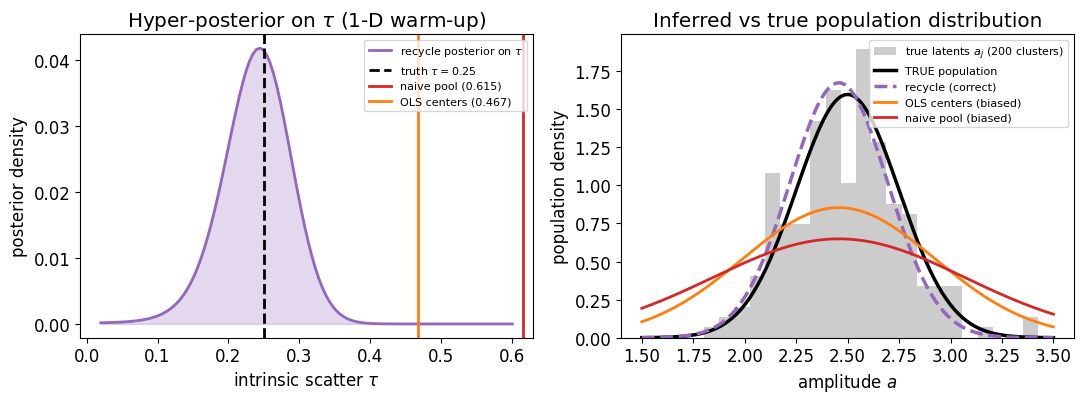

In [15]:
# Visualise: hyper-posterior on (mu, tau) with the three point estimates as vertical lines
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(tau_grid_w, tau_post, color="tab:purple", lw=2, label="recycle posterior on $\\tau$")
ax[0].fill_between(tau_grid_w, 0, tau_post, color="tab:purple", alpha=0.25)
ax[0].axvline(tau_w,     color="k",          ls="--", lw=2, label="truth $\\tau=0.25$")
ax[0].axvline(tau_pool_w, color="tab:red",    lw=2, label=f"naive pool ({tau_pool_w:.3f})")
ax[0].axvline(tau_ols_w,  color="tab:orange", lw=2, label=f"OLS centers ({tau_ols_w:.3f})")
ax[0].set_xlabel(r"intrinsic scatter $\tau$"); ax[0].set_ylabel("posterior density"); ax[0].set_title("Hyper-posterior on $\\tau$ (1-D warm-up)"); ax[0].legend(fontsize=8)

# Inferred population distribution vs the actual latent a_j
xx = np.linspace(mu_w - 4*tau_w, mu_w + 4*tau_w, 200)
gauss = lambda x, m, s: np.exp(-0.5*((x-m)/s)**2) / (s*np.sqrt(2*np.pi))
ax[1].hist(a_true_w, bins=22, density=True, color="0.8", label=f"true latents $a_j$ ({N_w} clusters)")
ax[1].plot(xx, gauss(xx, mu_w,        tau_w),     "k-",  lw=2.5, label=r"TRUE population")
ax[1].plot(xx, gauss(xx, d_w.mean(),  tau_rcy_w), "--",  color="tab:purple", lw=2.5, label="recycle (correct)")
ax[1].plot(xx, gauss(xx, d_w.mean(),  tau_ols_w), "-",   color="tab:orange", lw=2, label="OLS centers (biased)")
ax[1].plot(xx, gauss(xx, d_w.mean(),  tau_pool_w),"-",   color="tab:red",    lw=2, label="naive pool (biased)")
ax[1].set_xlabel("amplitude $a$"); ax[1].set_ylabel("population density"); ax[1].set_title("Inferred vs true population distribution"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

<font size='4'>7.1 Step 1 - fit over cluster (real per-cluster posteriors)</font>

Now we redo this same exercise on our 2-parameter fit line, where the per-cluster posterior is no longer analytic but now comes from MCMC.
Here we just are fitting over the clusters and finding out posterior.

In [16]:
# Run the per-cluster fit for every cluster in the population (§4 made `profiles`).
# We deliberately add EXTRA noise here so individual-cluster posteriors are wide -- otherwise the
# per-cluster scatter sigma_a << population tau_a and the three attempts below would look identical.
# This matches the real-WL regime: per-cluster mass uncertainty is comparable to the population scatter.
noise_dex_pc = 1.20                                  # heavier per-bin noise -> sigma_a ~ tau_a
# Bigger sample so the recycle posterior is tight enough to RESOLVE the OLS bias (~3.4 sigma sep.)
n_clusters_pc = 200
theta_true_pc = mu_pop + s_pop * np.random.randn(n_clusters_pc, 2)
profiles_pc   = np.array([profile_model(theta_true_pc[j]) + noise_dex_pc*np.random.randn(len(radii))
                          for j in range(n_clusters_pc)])

cluster_samples = []                                # list of (n_walkers*n_steps, 2) arrays, one per cluster
print(f"Fitting {n_clusters_pc} clusters individually (per-bin noise = {noise_dex_pc} dex)...")
for j in range(n_clusters_pc):
    with pm.Model() as model:
        # same priors as your log_prior()
        a = pm.Uniform("a", 0, 5)
        b = pm.Uniform("b", 0, 3)
        # profile_model(theta)
        mu = a - b * log_r
        # likelihood
        pm.Normal(
            "obs",
            mu=mu,
            sigma=noise_dex_pc,
            observed=profiles_pc[j]
        )
        trace = pm.sample(
            draws=2000,
            tune=500,
            chains=4,
            target_accept=0.9,
            progressbar=False
        )
    s = np.column_stack([
        trace.posterior["a"].values.reshape(-1),
        trace.posterior["b"].values.reshape(-1),
    ])
    cluster_samples.append(s)
cluster_samples = np.array(cluster_samples)         # shape: (n_clusters_pc, S, 2)
print("cluster_samples shape =", cluster_samples.shape, " (clusters, posterior samples, params)")
print("   <- this is what a WL pipeline gives you per cluster: a chain on (mass, concentration)")

Initializing NUTS using jitter+adapt_diag...


Fitting 200 clusters individually (per-bin noise = 1.2 dex)...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]
Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]
Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]
Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]
Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]
Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adap

cluster_samples shape = (200, 8000, 2)  (clusters, posterior samples, params)
   <- this is what a WL pipeline gives you per cluster: a chain on (mass, concentration)


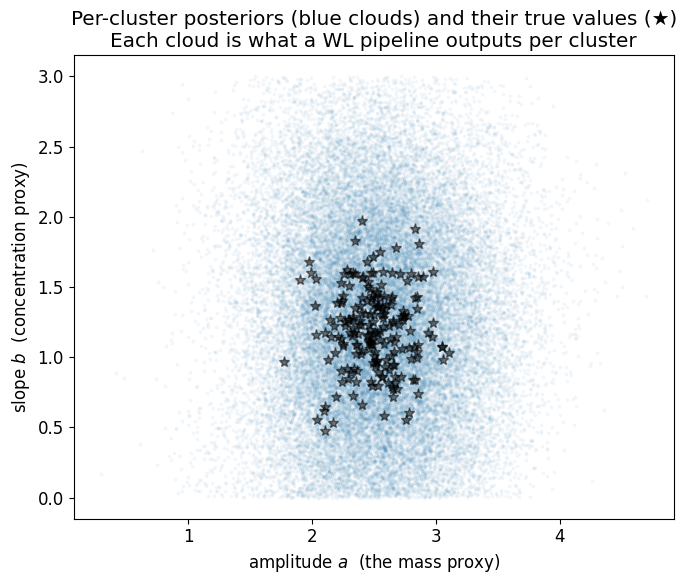

In [17]:
# Look at the per-cluster posteriors -- the raw material we will RECYCLE.
fig, ax = plt.subplots(figsize=(7, 6))
for j in range(n_clusters_pc):
    s = cluster_samples[j]
    ax.scatter(s[::40, 0], s[::40, 1], s=3, alpha=0.04, color="tab:blue")
    ax.plot(theta_true_pc[j, 0], theta_true_pc[j, 1], "k*", ms=8, alpha=0.5)
ax.set_xlabel("amplitude $a$  (the mass proxy)"); ax.set_ylabel("slope $b$  (concentration proxy)")
ax.set_title("Per-cluster posteriors (blue clouds) and their true values (★)\nEach cloud is what a WL pipeline outputs per cluster")
plt.tight_layout(); plt.show()

Each blue cloud is one cluster's posterior - a finite-S sample from p(&theta;<sub>j</sub> | $d_j$), centered roughly on its true &theta;<sub>j</sub> (&star;) but with substantial uncertainty (stacking won't tighten one cluster but stacking the population will tighten &Alpha;). We now want the mean and intrinisic scatter of the amplitudes from these clouds alone.

<font size='4'>7.2 Attempt 1 (wrong) - pool the per cluster samples and take their mean & std</font>

The simplest thing: dump every sample from every cluster into one big bag, then take its mean and std.

In [18]:
# pool: concatenate all per-cluster posterior samples for parameter `a` -- one giant bag
pooled_a = cluster_samples[:, :, 0].ravel()
mu_pool   = pooled_a.mean()
tau_pool  = pooled_a.std()
print("naive pool:  mu_a = %.3f   tau_a = %.3f   (truth: mu_a = %.2f, tau_a = %.2f)"
      % (mu_pool, tau_pool, mu_pop[0], s_pop[0]))
print("            -> tau_a is INFLATED: it absorbs the per-cluster posterior width on top of the true scatter.")

naive pool:  mu_a = 2.530   tau_a = 0.515   (truth: mu_a = 2.50, tau_a = 0.25)
            -> tau_a is INFLATED: it absorbs the per-cluster posterior width on top of the true scatter.


The pooled spread equals (true population scatter) &#8857; (per-cluster posterior width) - measurement noise is added instead of deconvolved. This is exactly the bias from Tutorial 2's flat-prior recycle, in 1-D form.

<font size='4'>8.3 Attempt 2 (also wrong) - OLS on the per-cluster centers</font>

What is we just take each cluster's posterior mean as its "best-fit a", then take the spread of those centers? That's classical regression on point-estimates

In [19]:
a_hat = cluster_samples[:, :, 0].mean(axis=1)    # one number per cluster: the posterior mean of a_j
mu_ols  = a_hat.mean()
tau_ols = a_hat.std()
print("OLS on centers:  mu_a = %.3f   tau_a = %.3f   (truth %.2f, %.2f)"
      % (mu_ols, tau_ols, mu_pop[0], s_pop[0]))
print("                 -> still off: tau_a sees scatter(true theta_j) ⊕ scatter(posterior centers)")

OLS on centers:  mu_a = 2.530   tau_a = 0.412   (truth 2.50, 0.25)
                 -> still off: tau_a sees scatter(true theta_j) ⊕ scatter(posterior centers)


The centers $â_j$ scatter by both the true population scatter &tau;<sup>2</sup><sub>a</sub> and the per-cluster posterior width &sigma;<sup>2</sup><sub>a</sub>(Var($â_j$) =  &tau;<sup>2</sup><sub>a</sub> + &sigma;<sup>2</sup><sub>a</sub>). So &tau;<sub>OLS</sub> over-estimates the truth (same convolution as Attempt 1, just slightly less inflated). Thus this is biased too.

<font size='4'>8.4 Attempt 3 (right) - importance-sampling reuse</font>

The honest answer marginalizes over each cluster's latent &theta;<sub>j</sub> instead of collapsing it to one number. 

In [20]:
# IMPORTANCE-SAMPLING RECYCLE -- one function = the integral above, evaluated S samples at a time.
# Each line is annotated with the matching piece of the recycling identity.
import pytensor.tensor as pt
a_samples = cluster_samples[:, :, 0]                  # theta_j^(s) for the amplitude, shape (N_c, S)

def hyper_logpost(params):
    mu, lt = params
    tau = pt.exp(lt)
    total = 0.0
    for j in range(n_clusters_pc):
        pop_density = (
            pt.exp(-0.5 * ((a_samples[j] - mu)/tau)**2)
            / tau
        )
        mc_integral = pt.mean(pop_density)
        total += pt.log(mc_integral + 1e-300)
    return total + lt

mu_a_true, tau_a_true = mu_pop[0], s_pop[0]
with pm.Model() as hyper_model:

    mu = pm.Flat("mu")
    lt = pm.Uniform("lt", -10, np.log(3))

    tau = pt.exp(lt)

    total = 0

    a_samples_pt = pt.as_tensor_variable(a_samples)

    pop_density = pt.exp(
        -0.5 * ((a_samples_pt - mu) / tau) ** 2
    ) / tau

    mc_integral = pt.mean(pop_density, axis=1)

    total = pt.sum(pt.log(mc_integral + 1e-300))

    pm.Potential("lp", total + lt)


    hyper_trace = pm.sample(
        draws=3000,
        tune=1500,
        chains=4,
        step=pm.Metropolis(),
        progressbar=False,
    )
mu_hat = hyper_trace.posterior["mu"].values.reshape(-1)
tau_hat = np.exp(
    hyper_trace.posterior["lt"].values.reshape(-1)
)
print("\nrecycle (Attempt 3):  mu_a = %.3f ± %.3f   tau_a = %.3f ± %.3f" %
      (mu_hat.mean(), mu_hat.std(), tau_hat.mean(), tau_hat.std()))
print("                       truth: mu_a = %.2f   tau_a = %.2f" % (mu_a_true, tau_a_true))

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [lt]
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
Sampling 4 chains for 1_500 tune and 3_000 draw iterations (6_000 + 12_000 draws total) took 284 seconds.



recycle (Attempt 3):  mu_a = 2.529 ± 0.030   tau_a = 0.273 ± 0.032
                       truth: mu_a = 2.50   tau_a = 0.25


In [22]:
print("                        mu_a       tau_a    | comment")
print("truth                :  %.3f      %.3f"                       % (mu_a_true, tau_a_true))
print("(1) naive pool       :  %.3f      %.3f    | biased: tau_a inflated by per-cluster scatter" % (mu_pool, tau_pool))
print("(2) OLS on centers   :  %.3f      %.3f    | biased: tau_a inflated by Var(centers)=tau^2+sigma^2" % (mu_ols, tau_ols))
print("(3) recycle (IS)     :  %.3f      %.3f    | CORRECT (uncertainty: ±%.3f, ±%.3f)"
      % (mu_hat.mean(), tau_hat.mean(), mu_hat.std(), tau_hat.std()))

                        mu_a       tau_a    | comment
truth                :  2.500      0.250
(1) naive pool       :  2.530      0.515    | biased: tau_a inflated by per-cluster scatter
(2) OLS on centers   :  2.530      0.412    | biased: tau_a inflated by Var(centers)=tau^2+sigma^2
(3) recycle (IS)     :  2.529      0.273    | CORRECT (uncertainty: ±0.030, ±0.032)


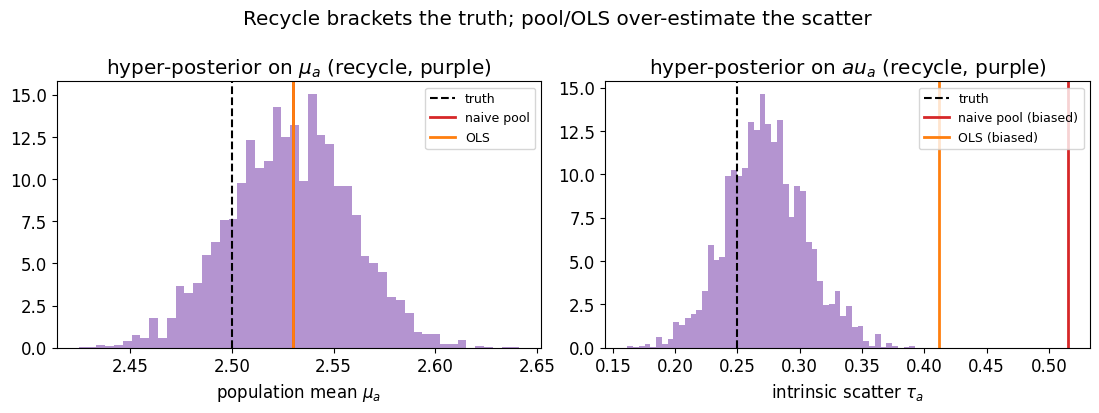

In [23]:
# The hyper-posterior in (mu_a, tau_a) -- our uncertainty on the POPULATION parameters.
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].hist(mu_hat, 50, density=True, color="tab:purple", alpha=0.7); ax[0].axvline(mu_a_true, color="k", ls="--", label="truth")
ax[0].axvline(mu_pool, color="tab:red", lw=2, label="naive pool"); ax[0].axvline(mu_ols, color="tab:orange", lw=2, label="OLS")
ax[0].set_xlabel(r"population mean $\mu_a$"); ax[0].set_title("hyper-posterior on $\mu_a$ (recycle, purple)"); ax[0].legend(fontsize=9)
ax[1].hist(tau_hat, 50, density=True, color="tab:purple", alpha=0.7); ax[1].axvline(tau_a_true, color="k", ls="--", label="truth")
ax[1].axvline(tau_pool, color="tab:red", lw=2, label="naive pool (biased)"); ax[1].axvline(tau_ols, color="tab:orange", lw=2, label="OLS (biased)")
ax[1].set_xlabel(r"intrinsic scatter $\tau_a$"); ax[1].set_title("hyper-posterior on $\tau_a$ (recycle, purple)"); ax[1].legend(fontsize=9)
plt.suptitle("Recycle brackets the truth; pool/OLS over-estimate the scatter"); plt.tight_layout(); plt.show()

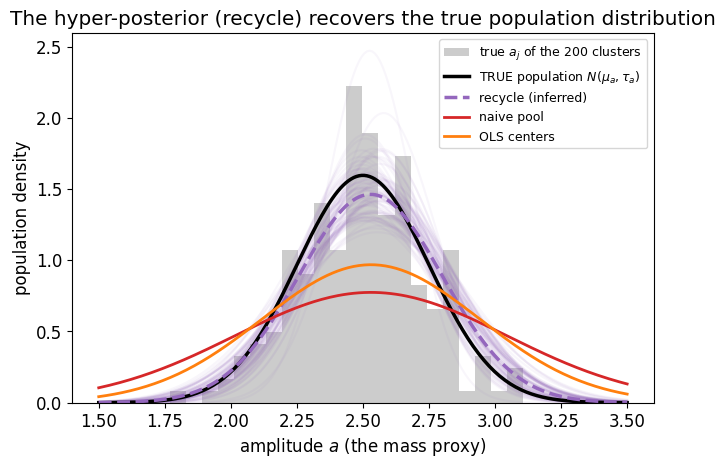

In [24]:
# Does the inferred population distribution match the actual cluster spread?
xx = np.linspace(mu_a_true - 4*tau_a_true, mu_a_true + 4*tau_a_true, 200)
gauss = lambda x, m, s: np.exp(-0.5*((x-m)/s)**2) / (s*np.sqrt(2*np.pi))
plt.figure(figsize=(7.5, 4.8))
plt.hist(theta_true_pc[:, 0], bins=22, density=True, color="0.8", label="true $a_j$ of the %d clusters" % n_clusters_pc)
idx = np.random.randint(len(mu_hat), size=80)
for mh, th in zip(mu_hat[idx], tau_hat[idx]):                              # spaghetti from hyper-posterior
    plt.plot(xx, gauss(xx, mh, th), color="tab:purple", alpha=0.06)
plt.plot(xx, gauss(xx, mu_a_true,    tau_a_true),    "k-",  lw=2.5, label=r"TRUE population $N(\mu_a,\tau_a)$")
plt.plot(xx, gauss(xx, mu_hat.mean(), tau_hat.mean()), "--", color="tab:purple", lw=2.5, label="recycle (inferred)")
plt.plot(xx, gauss(xx, mu_pool,       tau_pool),    "-",  color="tab:red",    lw=2.0, label="naive pool")
plt.plot(xx, gauss(xx, mu_ols,        tau_ols),     "-",  color="tab:orange", lw=2.0, label="OLS centers")
plt.xlabel("amplitude $a$ (the mass proxy)"); plt.ylabel("population density")
plt.title("The hyper-posterior (recycle) recovers the true population distribution"); plt.legend(fontsize=9); plt.show()

The purppple band - population distributions drawn from our hyper-posterior - brackets the truth (solid black) and matches the historgram of the actual cluster $a_j$. The red and orange curves (pool/ OLS) are too wide. Crucially we never re-fit a cluster for 8.4 - we recycled the stored per-cluster posteriors from 8.1. This is the engine of cluster mass calibration.